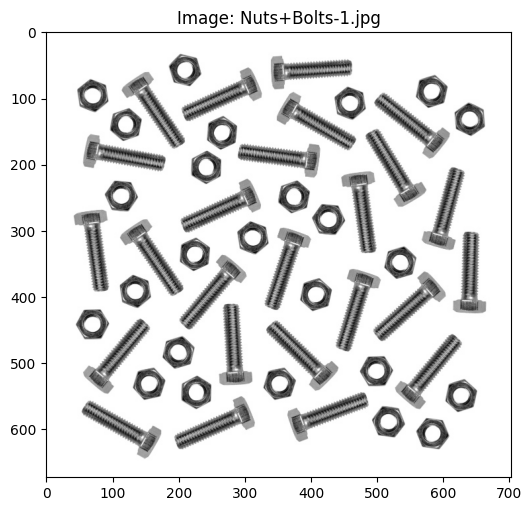

Detected: 25 nuts, 25 bolts
All good


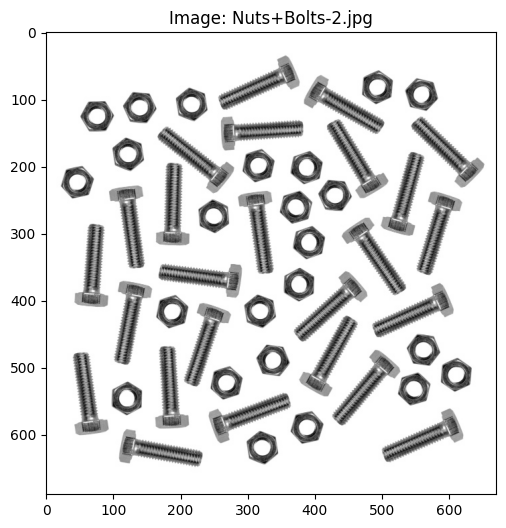

Detected: 24 nuts, 25 bolts
Add 1 nuts


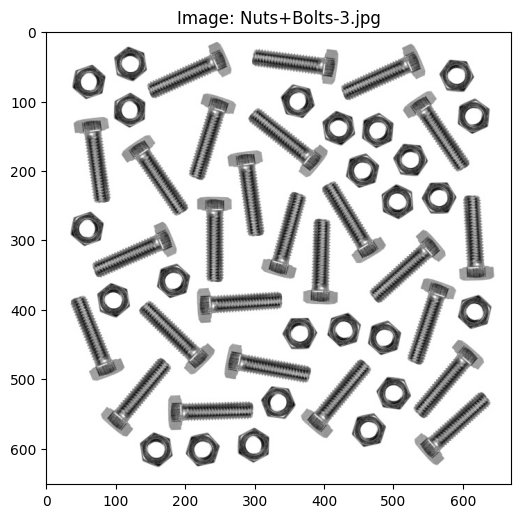

Detected: 25 nuts, 26 bolts
Remove 1 bolts


In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# init
folder = './images'
N = 25  # the total num
MIN_AREA = 500  # the min size of elements
NUT_HOLE_THRESHOLD = 0.3  # the raito of hole/nut

# input image and change into black and white
def init_image(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # change image into black and white
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # smooth the edges of nuts and bolts
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel) # fix the noise in elements
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel) # smooth the edge of elements

    return cleaned, img

# classify the nuts and bolts
def classify_components(binary_mask):
    # analyse the continued pixels to find elements
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

    nuts = 0
    bolts = 0

    for i in range(1, num_labels):  # skip background
        area = stats[i, cv2.CC_STAT_AREA]
        if area < MIN_AREA:
            continue

        # copy each element into a new iamge
        component_mask = (labels == i).astype(np.uint8) * 255

        # plt.imshow(component_mask)
        # plt.title(f"Image: {filename}")
        # plt.show()

        # use the edge to fill the holes of nuts and caculate the size of the whole
        filled = component_mask.copy()
        contours, hierarchy = cv2.findContours(filled, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
        for idx, h in enumerate(hierarchy[0]):
            if h[3] != -1:  # find the insede edge of nut
                cv2.drawContours(filled, contours, idx, 255, thickness=-1) # paint the area inside the nut

        # plt.imshow(filled)
        # plt.title(f"Image: {filename}")
        # plt.show() 

        area_original = np.sum(component_mask == 255)
        area_filled = np.sum(filled == 255)
        hole_area = area_filled - area_original
        hole_ratio = hole_area / float(area_original) # the raito used to classify if the element is a nut
        
        # print(f"Component {i}: contours found = {len(contours)}")
        # print(f"Component {i}: area={area_original}, hole_ratio={hole_ratio:.4f}")

        # classify the nut by if there is a hole inside the image
        if hole_ratio > NUT_HOLE_THRESHOLD:
            nuts += 1
        else:
            bolts += 1

    return nuts, bolts

# out put the result
def report(nuts, bolts, expected=N):
    print(f"Detected: {nuts} nuts, {bolts} bolts")

    actions = []
    if nuts < expected:
        actions.append(f"Add {expected - nuts} nuts")
    elif nuts > expected:
        actions.append(f"Remove {nuts - expected} nuts")

    if bolts < expected:
        actions.append(f"Add {expected - bolts} bolts")
    elif bolts > expected:
        actions.append(f"Remove {bolts - expected} bolts")

    if not actions:
        print("All good")
    else:
        print(", ".join(actions))

# process
def num_of_elements(image_path):
    binary, original = init_image(image_path)
    nuts, bolts = classify_components(binary)
    report(nuts, bolts)

# main
for filename in os.listdir(folder):
    if filename.lower().endswith(('.jpg')):
        image_path = os.path.join(folder, filename)
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img_rgb)
        plt.title(f"Image: {filename}")
        plt.show()
        num_of_elements(image_path)
